# Titre du notebook

In [1]:
# ============================================================
# Notebook : iris_pipeline.ipynb
# Projet IA - Dataset Iris
# Objectif :
# 1. Extraire les données
# 2. Explorer les données
# 3. Nettoyer les données
# 4. Prétraiter les données
# 5. Entraîner un modèle IA
# 6. Évaluer le modèle
# ============================================================

## Import des bibliothèques

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Configuration d’affichage

In [11]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

## Chargement du dataset CSV

In [17]:
print("Répertoire courant :", os.getcwd())
print("Contenu :", os.listdir())

Répertoire courant : /home/inaya/projet_iris/notebooks
Contenu : ['iris_pipeline.ipynb']


In [15]:
print(Path.cwd())
print((Path.cwd() / "data" / "raw" / "iris.csv").exists())
print((Path.cwd() / ".." / "data" / "raw" / "iris.csv").exists())

/home/inaya/projet_iris/notebooks
False
True


In [18]:
# Chemin du fichier CSV
file_path = "../data/raw/iris.csv"

# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Affichage des 5 premières lignes
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Dimensions du dataset

In [20]:
print("Nombre de lignes et colonnes :", df.shape)

Nombre de lignes et colonnes : (150, 6)


## Informations générales

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## Statistiques descriptives

In [22]:
df.describe(include="all")

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


## Vérification des noms de colonnes

In [23]:
print("Colonnes avant nettoyage :")
print(df.columns.tolist())

Colonnes avant nettoyage :
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


## Nettoyage des noms de colonnes

In [24]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("Colonnes après nettoyage :")
print(df.columns.tolist())

Colonnes après nettoyage :
['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm', 'species']


## Vérification des valeurs manquantes

In [25]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
id               0
sepallengthcm    0
sepalwidthcm     0
petallengthcm    0
petalwidthcm     0
species          0
dtype: int64


## Vérification des doublons

In [26]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## Suppression des doublons

In [28]:
df = df.drop_duplicates()
print("Nouvelle taille du dataset après suppression des doublons :", df.shape)

Nouvelle taille du dataset après suppression des doublons : (150, 6)


## Traitement des valeurs manquantes

In [29]:
# Pour les colonnes numériques : remplacement par la moyenne
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

# Pour les colonnes catégorielles : remplacement par la modalité la plus fréquente
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Valeurs manquantes après traitement :")
print(df.isnull().sum())

Valeurs manquantes après traitement :
id               0
sepallengthcm    0
sepalwidthcm     0
petallengthcm    0
petalwidthcm     0
species          0
dtype: int64


/tmp/ipykernel_23138/3162012748.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


## Vérification des valeurs uniques de la cible

In [30]:
print("Valeurs uniques de la colonne cible :")
print(df["species"].unique())

Valeurs uniques de la colonne cible :
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


## Nettoyage des labels de la cible

In [31]:
df["species"] = df["species"].str.strip().str.lower()
print(df["species"].unique())

<StringArray>
['iris-setosa', 'iris-versicolor', 'iris-virginica']
Length: 3, dtype: str


## Aperçu final après nettoyage

In [32]:
df.head()

,id,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,1,5.1,3.5,1.4,0.2,iris-setosa
1,2,4.9,3.0,1.4,0.2,iris-setosa
2,3,4.7,3.2,1.3,0.2,iris-setosa
3,4,4.6,3.1,1.5,0.2,iris-setosa
4,5,5.0,3.6,1.4,0.2,iris-setosa


## Distribution des classes

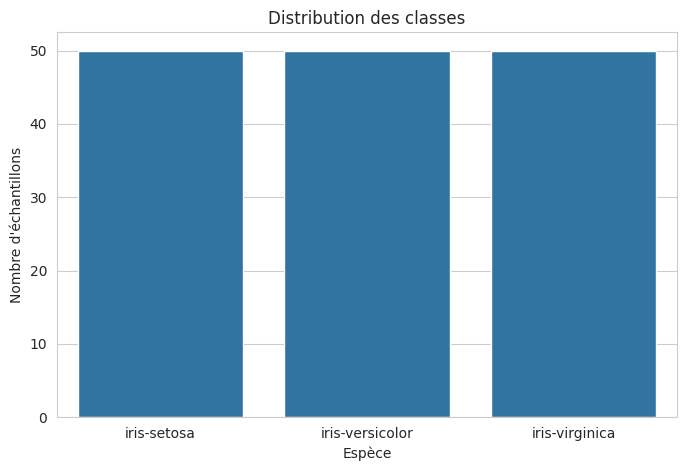

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species")
plt.title("Distribution des classes")
plt.xlabel("Espèce")
plt.ylabel("Nombre d'échantillons")
plt.show()

## Histogrammes des variables numériques

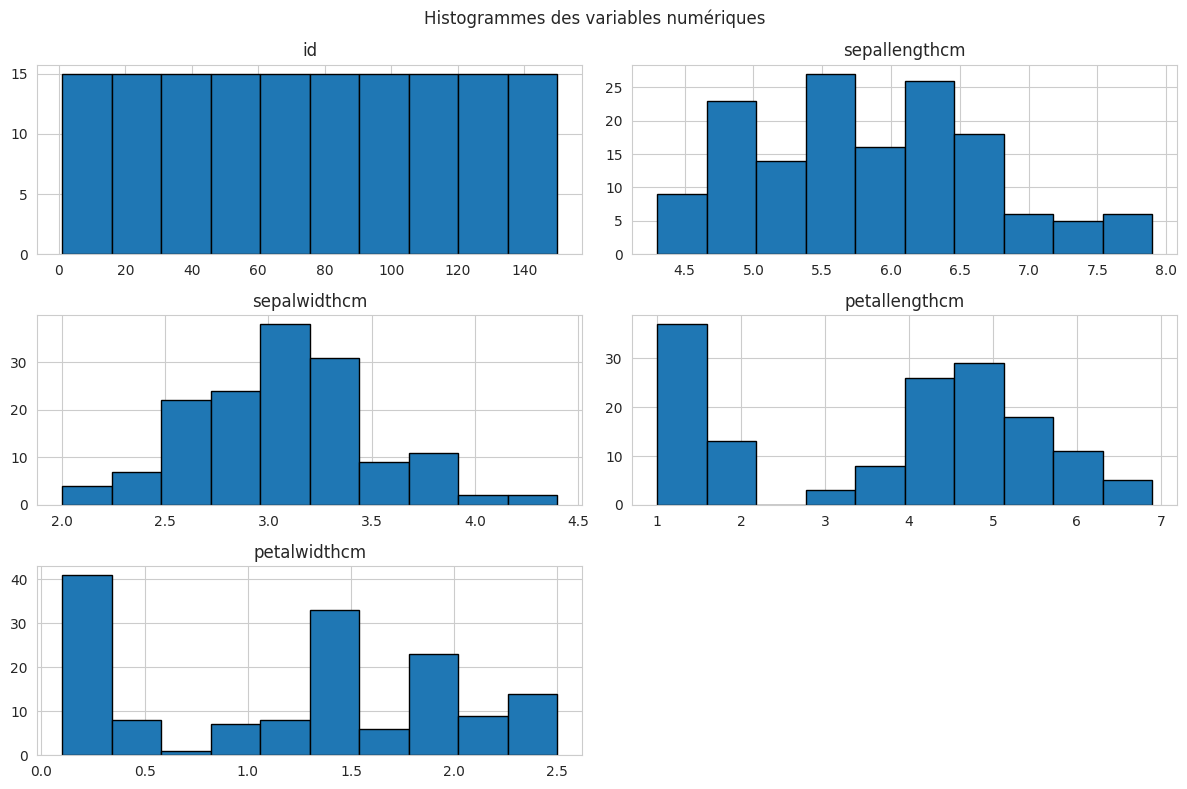

In [34]:
df.hist(figsize=(12, 8), edgecolor="black")
plt.suptitle("Histogrammes des variables numériques")
plt.tight_layout()
plt.show()

## Matrice de corrélation

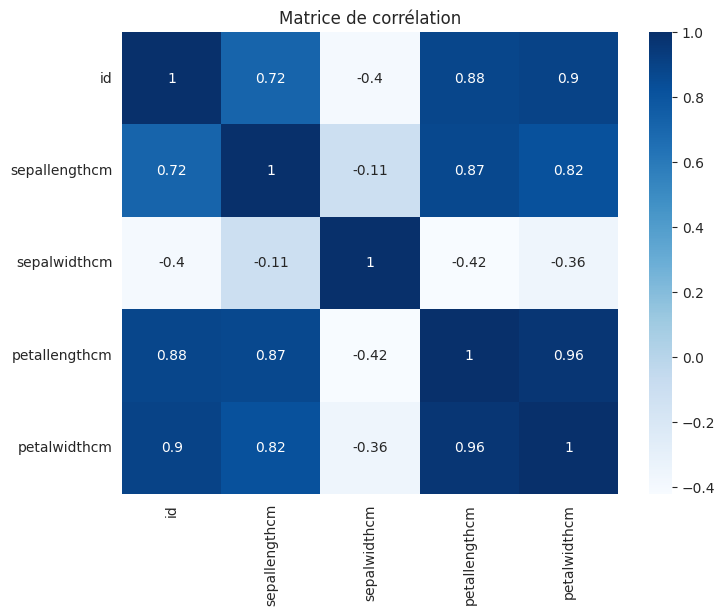

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="Blues")
plt.title("Matrice de corrélation")
plt.show()

## Pairplot

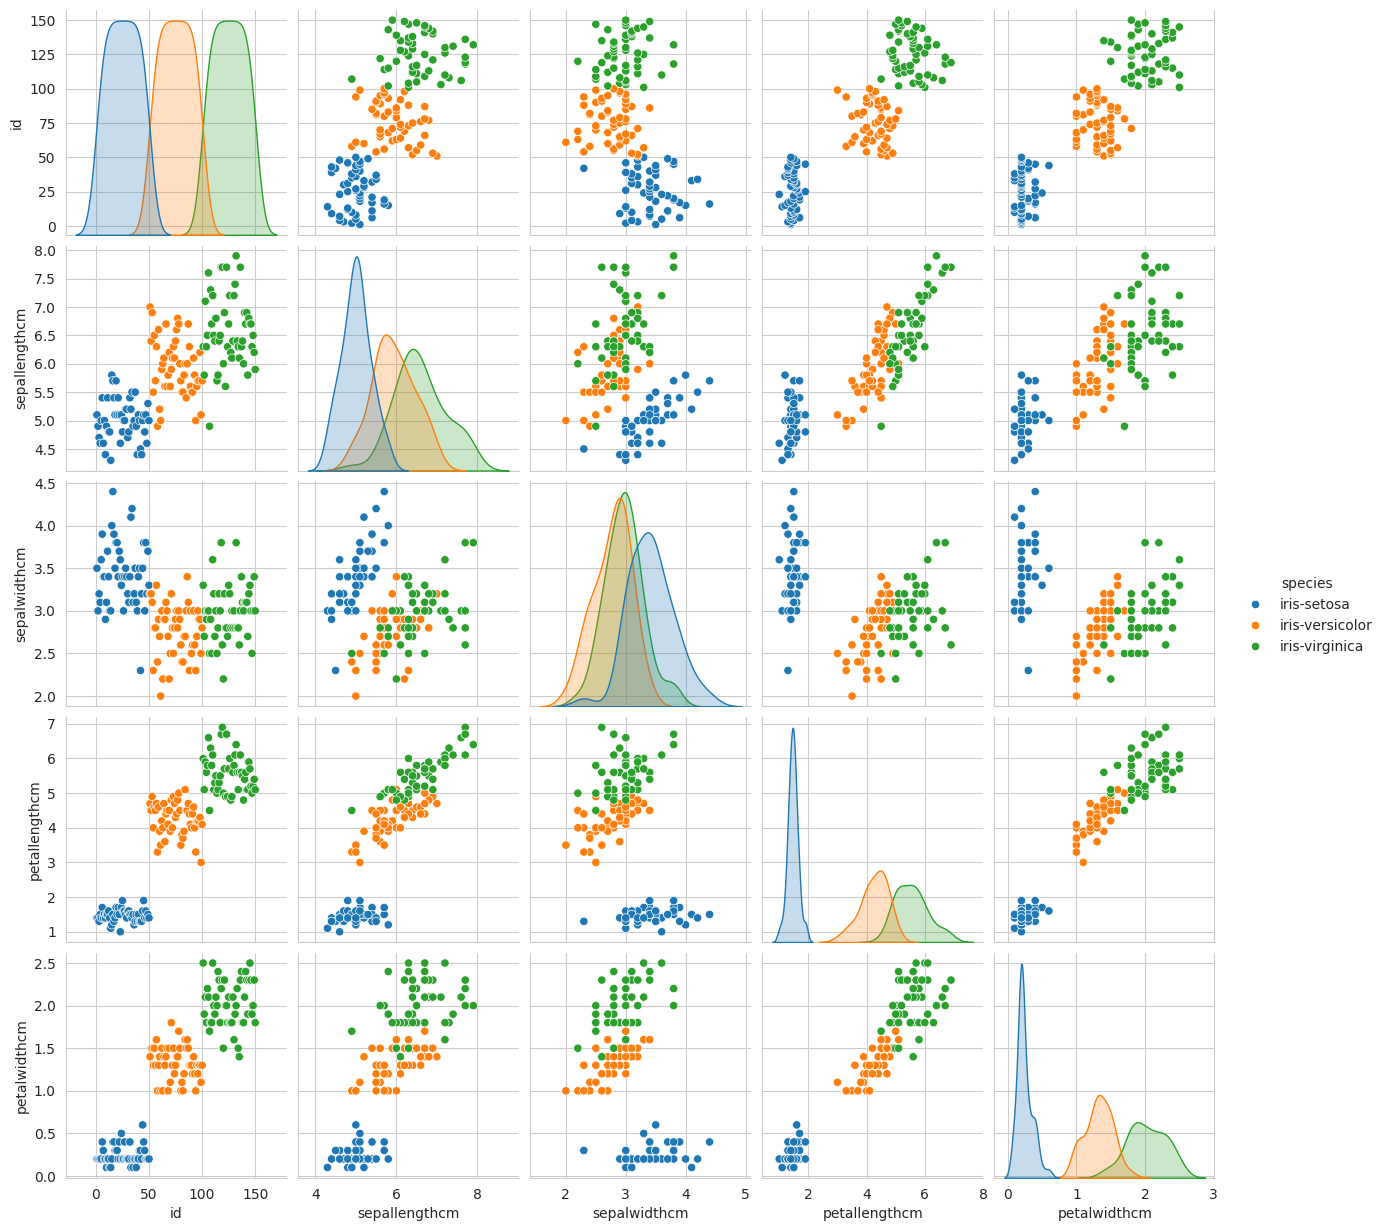

In [36]:
sns.pairplot(df, hue="species")
plt.show()

## Séparation variables explicatives / cible

In [48]:
X = df.drop(columns=["id", "species"])
y = df["species"]

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (150, 4)
y shape : (150,)


## Encodage de la cible

In [50]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes encodées :", label_encoder.classes_)
print("Aperçu y encodé :", y_encoded[:10])

Classes encodées : ['iris-setosa' 'iris-versicolor' 'iris-virginica']
Aperçu y encodé : [0 0 0 0 0 0 0 0 0 0]


## Split train / test

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (120, 4)
Taille X_test : (30, 4)
Taille y_train : (120,)
Taille y_test : (30,)


## Standardisation des variables

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Préprocessing terminé.")

Préprocessing terminé.


## Entraînement du modèle

In [53]:
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train_scaled, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## Prédictions

In [54]:
y_pred = model.predict(X_test_scaled)

print("Prédictions réalisées.")

Prédictions réalisées.


## Accuracy

In [55]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.9333333333333333


## Classification report

In [56]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print("Classification Report :")
print(report)

Classification Report :
                 precision    recall  f1-score   support

    iris-setosa       1.00      1.00      1.00        10
iris-versicolor       0.90      0.90      0.90        10
 iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## Matrice de confusion

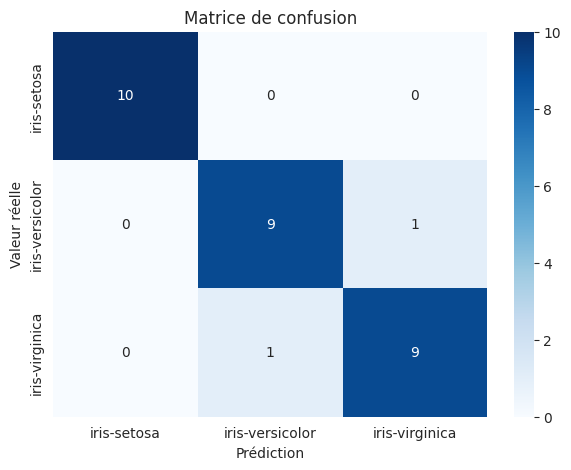

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.show()

## Test d’une prédiction simple

In [58]:
print("Colonnes de df :", df.columns.tolist())
print("Colonnes de X :", X.columns.tolist())
print("Shape de X :", X.shape)

Colonnes de df : ['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm', 'species']
Colonnes de X : ['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm']
Shape de X : (150, 4)


In [59]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)
predicted_label = label_encoder.inverse_transform(prediction)

print("Classe prédite :", predicted_label[0])

Classe prédite : iris-setosa


/home/inaya/miniconda3/envs/projet_iris/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Sauvegarde des artefacts

In [60]:
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(model, "../artifacts/iris_model.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")
joblib.dump(label_encoder, "../artifacts/label_encoder.pkl")

print("Modèle, scaler et label encoder sauvegardés dans ../artifacts/")

Modèle, scaler et label encoder sauvegardés dans ../artifacts/


## Conclusion

In [61]:
print("Pipeline terminé avec succès.")
print("Le dataset a été extrait, exploré, nettoyé, prétraité, puis utilisé pour entraîner et évaluer un modèle de classification.")

Pipeline terminé avec succès.
Le dataset a été extrait, exploré, nettoyé, prétraité, puis utilisé pour entraîner et évaluer un modèle de classification.
